# Phase 1: Advanced Scientific Translation for Arabic Abstracts
## Using the ASCAT Dataset

**Objective:** Develop an English-to-Arabic translation system for scientific abstracts that preserves meaning, structure, and scientific terminology.

**Dataset:** [NAMAA-Space/ASCAT-Arabic-Scientific-Translation](https://huggingface.co/datasets/NAMAA-Space/ASCAT-Arabic-Scientific-Translation)

---

### Outline
1. Dataset Exploration
2. Data Preprocessing
3. Visualization
4. Literature Review
5. Pipeline & Proposed Methodology

In [ ]:
%pip install pandas matplotlib seaborn wordcloud nltk scikit-learn arabic-reshaper python-bidi -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter
from wordcloud import WordCloud
from bidi.algorithm import get_display
import arabic_reshaper
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
# 1. Dataset Exploration

In [ ]:
df = pd.read_csv("hf://datasets/NAMAA-Space/ASCAT-Arabic-Scientific-Translation/abstracts_with_stats_clean.csv")
df = df.drop(columns=['Unnamed: 0'])
df.shape

(536, 8)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   arabic_abstract              536 non-null    str  
 1   original_abstract            536 non-null    str  
 2   arabic_abstract_words        536 non-null    int64
 3   arabic_abstract_chars        536 non-null    int64
 4   arabic_abstract_sentences    536 non-null    int64
 5   original_abstract_words      536 non-null    int64
 6   original_abstract_chars      536 non-null    int64
 7   original_abstract_sentences  536 non-null    int64
dtypes: int64(6), str(2)
memory usage: 33.6 KB


In [ ]:
df.head(3)

,arabic_abstract,original_abstract,arabic_abstract_words,arabic_abstract_chars,arabic_abstract_sentences,original_abstract_words,original_abstract_chars,original_abstract_sentences
0,نقوم بحساب الحلول الأساسية المعتدلة للمؤثرات ا...,We compute temperate fundamental solutions of ...,34,252,3,40,320,3
1,تطوّر هذه الورقة تقنية تغذية راجعة انتقائية قا...,This paper develops a contention-based opportu...,100,641,7,106,735,7
2,في حلقة من مادة فائقة التوصيل من النمط S، يتم ...,In a ring of s-wave superconducting material t...,98,555,6,110,683,6


In [ ]:
df.describe()

,arabic_abstract_words,arabic_abstract_chars,arabic_abstract_sentences,original_abstract_words,original_abstract_chars,original_abstract_sentences
count,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000
mean,111.972015,696.574627,6.996269,125.529851,823.488806,7.169776
std,58.756278,352.281719,3.731150,63.855554,404.988967,3.814275
min,4.000000,31.000000,1.000000,3.000000,30.000000,1.000000
25%,70.000000,443.750000,5.000000,78.000000,533.500000,5.000000
50%,100.000000,627.000000,6.000000,113.000000,745.500000,6.000000
75%,148.000000,910.000000,9.000000,164.000000,1067.000000,9.000000
max,315.000000,1905.000000,29.000000,297.000000,1866.000000,28.000000


In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
arabic_abstract,0,0.0
original_abstract,0,0.0
arabic_abstract_words,0,0.0
arabic_abstract_chars,0,0.0
arabic_abstract_sentences,0,0.0
original_abstract_words,0,0.0
original_abstract_chars,0,0.0
original_abstract_sentences,0,0.0


In [ ]:
pd.DataFrame({
    'Metric': ['Duplicate rows', 'Duplicate English texts', 'Duplicate Arabic texts'],
    'Count': [
        df.duplicated().sum(),
        df['original_abstract'].duplicated().sum(),
        df['arabic_abstract'].duplicated().sum()
    ]
}).set_index('Metric')

,Count
Metric,
Duplicate rows,0
Duplicate English texts,0
Duplicate Arabic texts,1


In [ ]:
domain_keywords = {
    'physics': ['physics', 'particle', 'electron', 'photon', 'magnetic', 'thermal', 'energy',
                'neutron', 'nuclear', 'plasma', 'optic', 'laser', 'wave', 'field', 'relativity',
                'gravitational', 'cosmolog', 'astrophys', 'electromagnetic', 'superconducti',
                'scattering', 'spectro', 'radiation', 'entropy', 'thermodynamic', 'boson', 'fermion'],
    'quantum_mechanics': ['quantum', 'qubit', 'entangle', 'superposition', 'decoherence',
                          'hamiltonian', 'wavefunction', 'hilbert', 'quantum comput',
                          'quantum state', 'quantum system', 'quantum information', 'unitary'],
    'mathematics': ['theorem', 'proof', 'algebra', 'topology', 'manifold', 'polynomial',
                    'conjecture', 'eigenvalue', 'matrix', 'differential equation', 'integral',
                    'convergence', 'lemma', 'banach', 'hilbert space', 'stochastic',
                    'combinatori', 'lattice', 'homomorph', 'isomorph', 'functor', 'cohomolog',
                    'finite group', 'prime', 'modular', 'arithmetic', 'riemannian'],
    'computer_science': ['algorithm', 'neural network', 'deep learning', 'machine learning',
                         'optimization', 'graph', 'database', 'software', 'compiler',
                         'distributed system', 'cloud', 'blockchain', 'cryptograph',
                         'complexity', 'programming', 'data structure', 'natural language',
                         'computer vision', 'reinforcement learning', 'classification',
                         'clustering', 'network', 'robotic', 'autonomous'],
    'artificial_intelligence': ['artificial intelligence', ' ai ', 'transformer', 'bert',
                                'language model', 'generative', 'gpt', 'attention mechanism',
                                'large language', 'llm', 'chatbot', 'sentiment analysis',
                                'text generation', 'image generation', 'diffusion model',
                                'prompt', 'fine-tun', 'pretrain', 'transfer learning']
}


def assign_domain(text):
    text_lower = text.lower()
    scores = {}
    for domain, keywords in domain_keywords.items():
        scores[domain] = sum(1 for kw in keywords if kw in text_lower)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'other'


df['domain'] = df['original_abstract'].apply(assign_domain)
df['domain'].value_counts()

domain
physics              314
other                 84
mathematics           76
computer_science      34
quantum_mechanics     28
Name: count, dtype: int64

In [ ]:
df['word_ratio'] = df['arabic_abstract_words'] / df['original_abstract_words'].replace(0, np.nan)

stats_cols = ['original_abstract_words', 'arabic_abstract_words',
              'original_abstract_chars', 'arabic_abstract_chars',
              'original_abstract_sentences', 'arabic_abstract_sentences', 'word_ratio']
df[stats_cols].describe().round(2)

,original_abstract_words,arabic_abstract_words,original_abstract_chars,arabic_abstract_chars,original_abstract_sentences,arabic_abstract_sentences,word_ratio
count,536.00,536.00,536.00,536.00,536.00,536.00,536.00
mean,125.53,111.97,823.49,696.57,7.17,7.00,0.98
std,63.86,58.76,404.99,352.28,3.81,3.73,1.98
min,3.00,4.00,30.00,31.00,1.00,1.00,0.23
25%,78.00,70.00,533.50,443.75,5.00,5.00,0.83
50%,113.00,100.00,745.50,627.00,6.00,6.00,0.89
75%,164.00,148.00,1067.00,910.00,9.00,9.00,0.94
max,297.00,315.00,1866.00,1905.00,28.00,29.00,46.67


In [ ]:
for i, row in df.sample(2, random_state=42).iterrows():
    display(pd.DataFrame({
        'Field': ['Domain', 'English (first 250 chars)', 'Arabic (first 250 chars)',
                  'EN words', 'AR words', 'Ratio'],
        'Value': [row['domain'], row['original_abstract'][:250],
                  row['arabic_abstract'][:250],
                  row['original_abstract_words'], row['arabic_abstract_words'],
                  round(row['word_ratio'], 2)]
    }).set_index('Field'))

,Value
Field,
Domain,other
English (first 250 chars),A complete set of polarization transfer observ...
Arabic (first 250 chars),تم قياس مجموعة كاملة من متغيرات نقل الاستقطاب ...
EN words,98
AR words,94
Ratio,0.96


,Value
Field,
Domain,mathematics
English (first 250 chars),In this paper we give a generalization of Cheb...
Arabic (first 250 chars),نقدم تقريراً عن نوع جديد من التجارب يمكّننا من...
EN words,40
AR words,100
Ratio,2.5


---
# 2. Data Preprocessing

Steps:
1. Remove duplicate translation pairs
2. Normalize English text (whitespace, encoding artifacts, URLs/HTML)
3. Normalize Arabic text (remove diacritics/Tashkeel, normalize Alef/Taa/Kashida)
4. Filter very short abstracts
5. Stratified train/val/test split
6. Handle domain imbalance via oversampling

In [ ]:
def clean_english(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    text = text.encode('utf-8', errors='ignore').decode('utf-8')
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text if len(text) > 0 else None


def normalize_arabic(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    text = text.encode('utf-8', errors='ignore').decode('utf-8')
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652\u0670]', '', text)
    text = re.sub(r'[\u0625\u0623\u0622\u0627]', '\u0627', text)
    text = re.sub(r'\u0629', '\u0647', text)
    text = re.sub(r'\u0649', '\u064A', text)
    text = re.sub(r'\u0640', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text if len(text) > 0 else None

In [ ]:
before_total = len(df)

df = df.drop_duplicates(subset=['original_abstract', 'arabic_abstract']).reset_index(drop=True)
after_dedup = len(df)

df['en_clean'] = df['original_abstract'].apply(clean_english)
df['ar_clean'] = df['arabic_abstract'].apply(normalize_arabic)

df = df.dropna(subset=['en_clean', 'ar_clean']).reset_index(drop=True)
after_na = len(df)

min_words = 10
df = df[
    (df['en_clean'].apply(lambda x: len(x.split()) >= min_words)) &
    (df['ar_clean'].apply(lambda x: len(x.split()) >= min_words))
].reset_index(drop=True)
after_filter = len(df)

df['en_words_clean'] = df['en_clean'].apply(lambda x: len(x.split()))
df['ar_words_clean'] = df['ar_clean'].apply(lambda x: len(x.split()))

pd.DataFrame({
    'Step': ['Original', 'After deduplication', 'After removing empty texts',
             f'After length filter (>= {min_words} words)'],
    'Rows': [before_total, after_dedup, after_na, after_filter]
}).set_index('Step')

,Rows
Step,
Original,536
After deduplication,536
After removing empty texts,536
After length filter (>= 10 words),533


In [ ]:
idx = 0
pd.DataFrame({
    'Version': ['Original English', 'Cleaned English', 'Original Arabic', 'Normalized Arabic'],
    'Text (first 300 chars)': [
        df.iloc[idx]['original_abstract'][:300],
        df.iloc[idx]['en_clean'][:300],
        df.iloc[idx]['arabic_abstract'][:300],
        df.iloc[idx]['ar_clean'][:300]
    ]
}).set_index('Version')

,Text (first 300 chars)
Version,
Original English,We compute temperate fundamental solutions of ...
Cleaned English,We compute temperate fundamental solutions of ...
Original Arabic,نقوم بحساب الحلول الأساسية المعتدلة للمؤثرات ا...
Normalized Arabic,نقوم بحساب الحلول الاساسيه المعتدله للمؤثرات ا...


## 2.1 Domain Imbalance Handling

According to the ASCAT paper, the dataset has a slight domain imbalance with mathematics being dominant. We use:
1. **Stratified splitting** to keep domain proportions in train/val/test
2. **Random oversampling** of minority domains in the training set

In [ ]:
from sklearn.model_selection import train_test_split

domain_counts = df['domain'].value_counts()

display(pd.DataFrame({
    'Domain': domain_counts.index,
    'Count': domain_counts.values,
    'Ratio vs Min': (domain_counts.values / domain_counts.min()).round(2)
}))

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['domain'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['domain'])

split_summary = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Size': [len(train_df), len(val_df), len(test_df)]
})
for d in sorted(df['domain'].unique()):
    split_summary[d] = [
        len(train_df[train_df['domain'] == d]),
        len(val_df[val_df['domain'] == d]),
        len(test_df[test_df['domain'] == d])
    ]
split_summary.set_index('Split')

,Domain,Count,Ratio vs Min
0,physics,313,11.18
1,other,84,3.00
2,mathematics,75,2.68
3,computer_science,33,1.18
4,quantum_mechanics,28,1.00


,Size,computer_science,mathematics,other,physics,quantum_mechanics
Split,,,,,,
Train,373,23,52,59,219,20
Validation,80,5,11,13,47,4
Test,80,5,12,12,47,4


In [ ]:
target_count = domain_counts.max()

oversampled_parts = []
for domain_name, group in train_df.groupby('domain'):
    if len(group) < target_count:
        oversampled_parts.append(group.sample(n=target_count, replace=True, random_state=42))
    else:
        oversampled_parts.append(group)

train_balanced = pd.concat(oversampled_parts, ignore_index=True)

pd.DataFrame({
    'Set': ['Original Train', 'Balanced Train'],
    'Size': [len(train_df), len(train_balanced)]
}).set_index('Set')

,Size
Set,
Original Train,373
Balanced Train,1565


---
# 3. Visualization

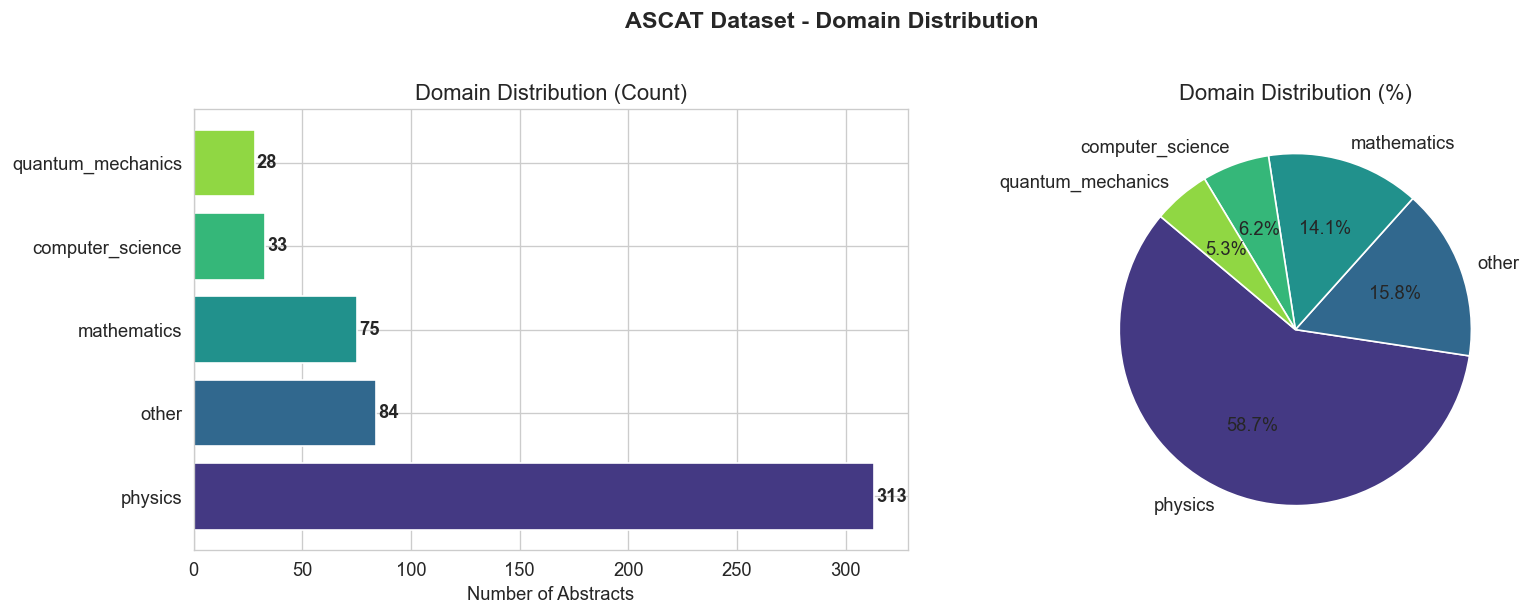

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

domain_counts = df['domain'].value_counts()
colors = sns.color_palette('viridis', len(domain_counts))

axes[0].barh(domain_counts.index, domain_counts.values, color=colors)
axes[0].set_xlabel('Number of Abstracts')
axes[0].set_title('Domain Distribution (Count)')
for i, v in enumerate(domain_counts.values):
    axes[0].text(v + 1, i, str(v), va='center', fontweight='bold')

axes[1].pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Domain Distribution (%)')

plt.suptitle('ASCAT Dataset - Domain Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

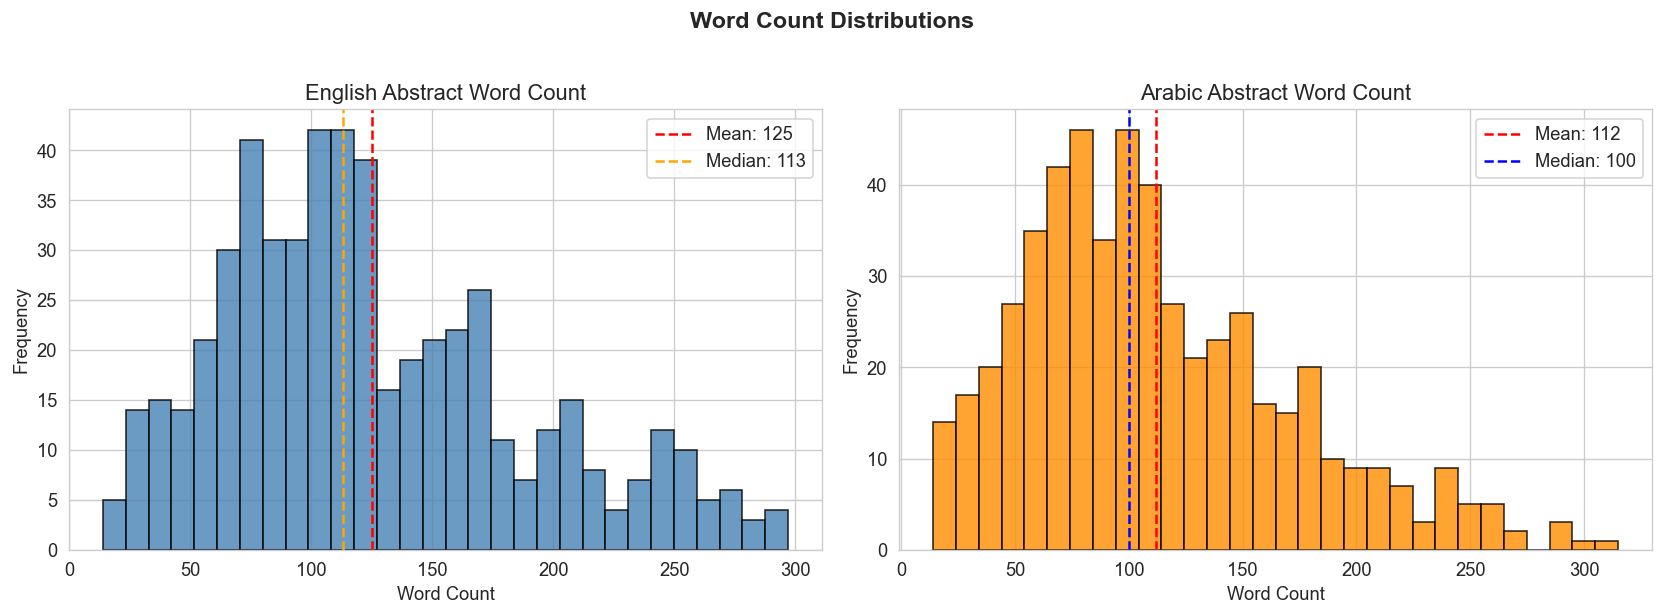

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['en_words_clean'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['en_words_clean'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['en_words_clean'].mean():.0f}")
axes[0].axvline(df['en_words_clean'].median(), color='orange', linestyle='--',
                label=f"Median: {df['en_words_clean'].median():.0f}")
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('English Abstract Word Count')
axes[0].legend()

axes[1].hist(df['ar_words_clean'], bins=30, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].axvline(df['ar_words_clean'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['ar_words_clean'].mean():.0f}")
axes[1].axvline(df['ar_words_clean'].median(), color='blue', linestyle='--',
                label=f"Median: {df['ar_words_clean'].median():.0f}")
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Arabic Abstract Word Count')
axes[1].legend()

plt.suptitle('Word Count Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

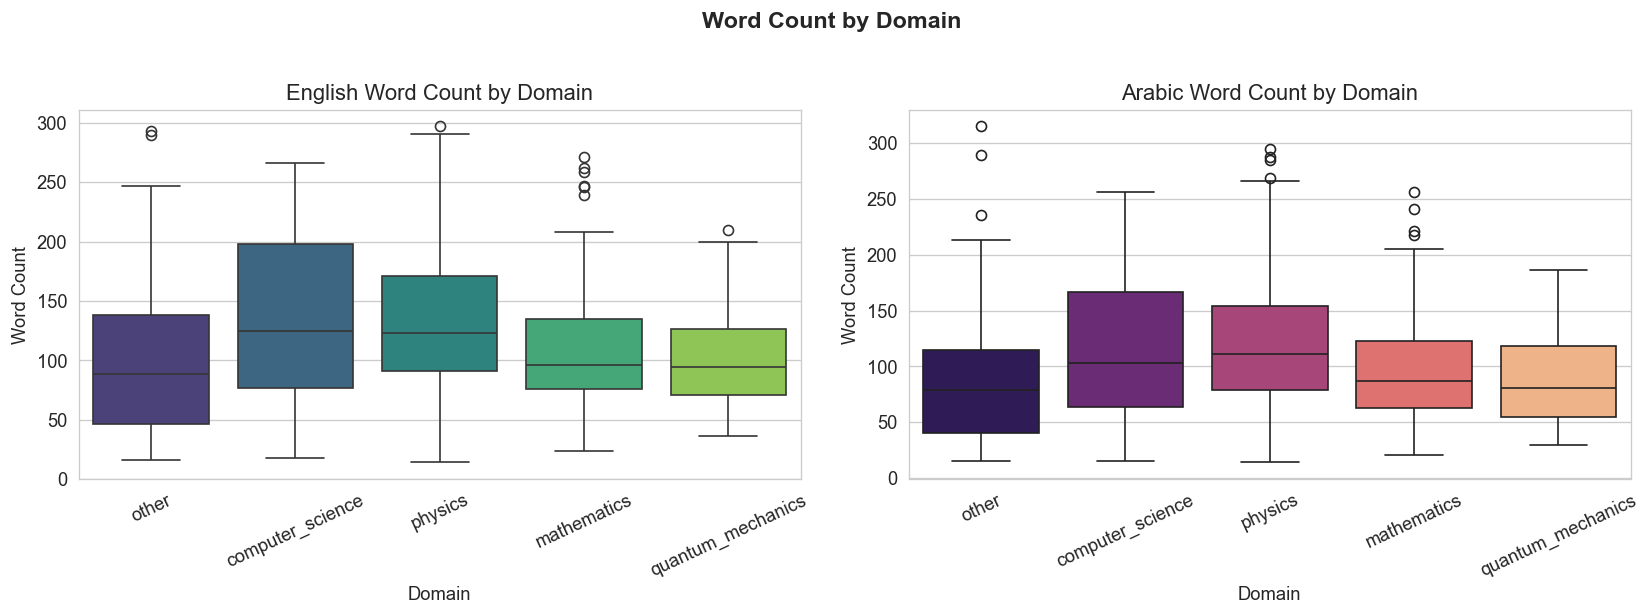

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='domain', y='en_words_clean', ax=axes[0], palette='viridis')
axes[0].set_title('English Word Count by Domain')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(data=df, x='domain', y='ar_words_clean', ax=axes[1], palette='magma')
axes[1].set_title('Arabic Word Count by Domain')
axes[1].set_xlabel('Domain')
axes[1].set_ylabel('Word Count')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Word Count by Domain', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

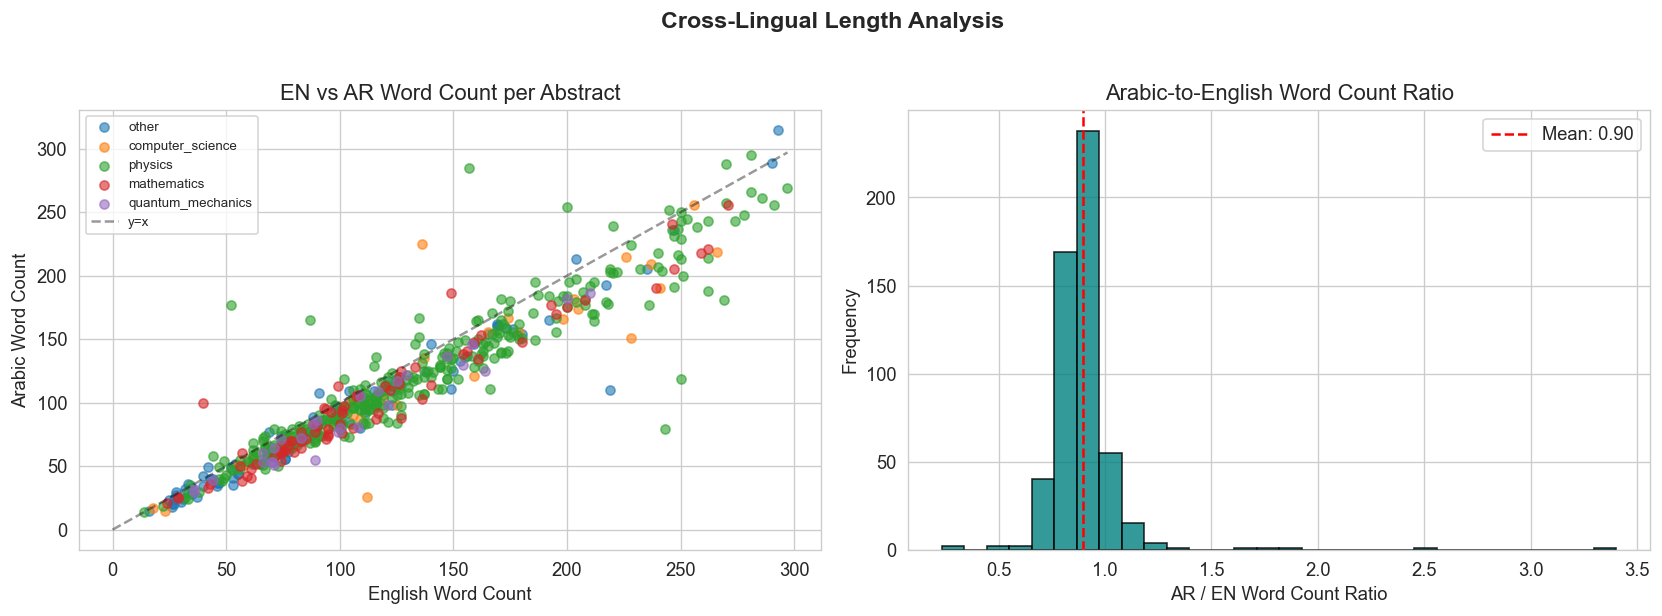

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for domain in df['domain'].unique():
    sub = df[df['domain'] == domain]
    axes[0].scatter(sub['en_words_clean'], sub['ar_words_clean'],
                    alpha=0.6, label=domain, s=30)
axes[0].plot([0, df['en_words_clean'].max()], [0, df['en_words_clean'].max()],
             'k--', alpha=0.4, label='y=x')
axes[0].set_xlabel('English Word Count')
axes[0].set_ylabel('Arabic Word Count')
axes[0].set_title('EN vs AR Word Count per Abstract')
axes[0].legend(fontsize=8)

ratio = df['ar_words_clean'] / df['en_words_clean']
axes[1].hist(ratio, bins=30, color='teal', edgecolor='black', alpha=0.8)
axes[1].axvline(ratio.mean(), color='red', linestyle='--',
                label=f'Mean: {ratio.mean():.2f}')
axes[1].set_xlabel('AR / EN Word Count Ratio')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Arabic-to-English Word Count Ratio')
axes[1].legend()

plt.suptitle('Cross-Lingual Length Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

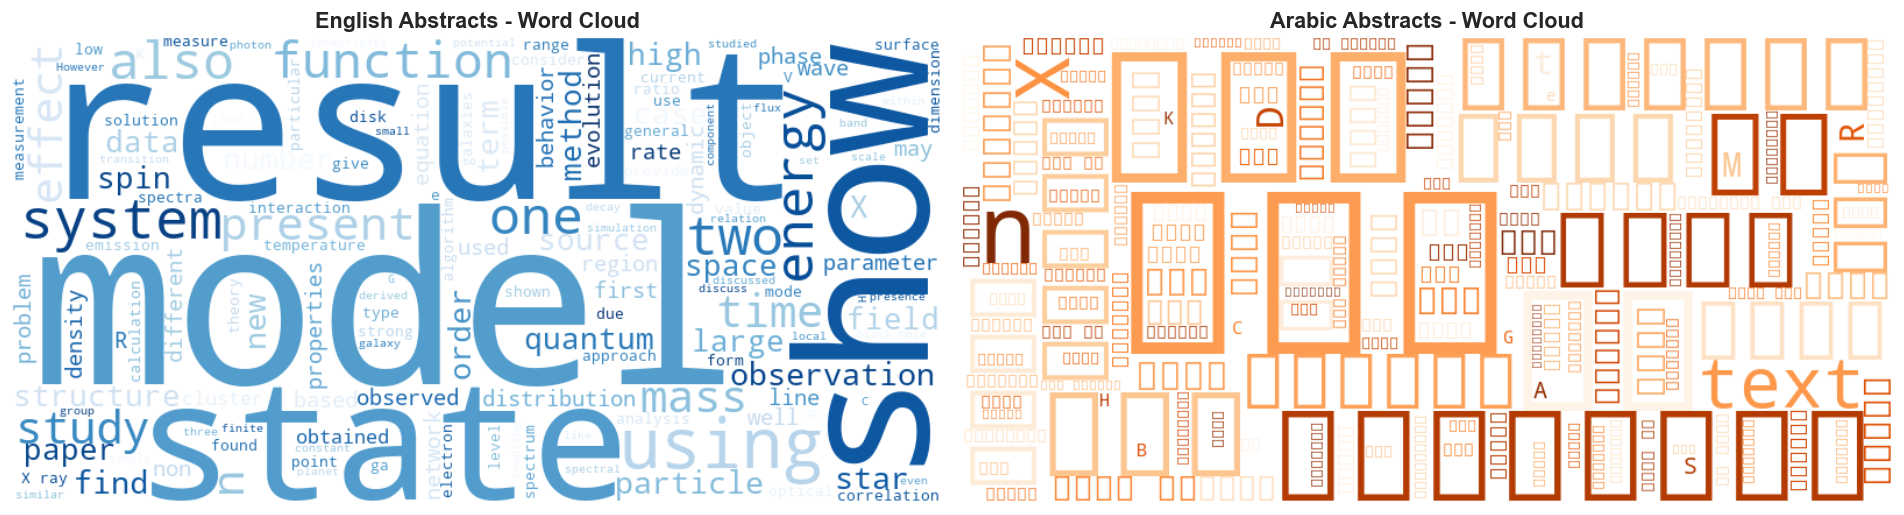

In [ ]:
en_stopwords = set(stopwords.words('english'))
ar_stopwords = set(stopwords.words('arabic'))

en_text = ' '.join(df['en_clean'].tolist())
ar_text = ' '.join(df['ar_clean'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_en = WordCloud(width=800, height=400, background_color='white',
                  stopwords=en_stopwords, max_words=150,
                  colormap='Blues').generate(en_text)
axes[0].imshow(wc_en, interpolation='bilinear')
axes[0].set_title('English Abstracts - Word Cloud', fontsize=13, fontweight='bold')
axes[0].axis('off')

wc_ar = WordCloud(width=800, height=400, background_color='white',
                  stopwords=ar_stopwords, max_words=150,
                  colormap='Oranges').generate(ar_text)
axes[1].imshow(wc_ar, interpolation='bilinear')
axes[1].set_title('Arabic Abstracts - Word Cloud', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

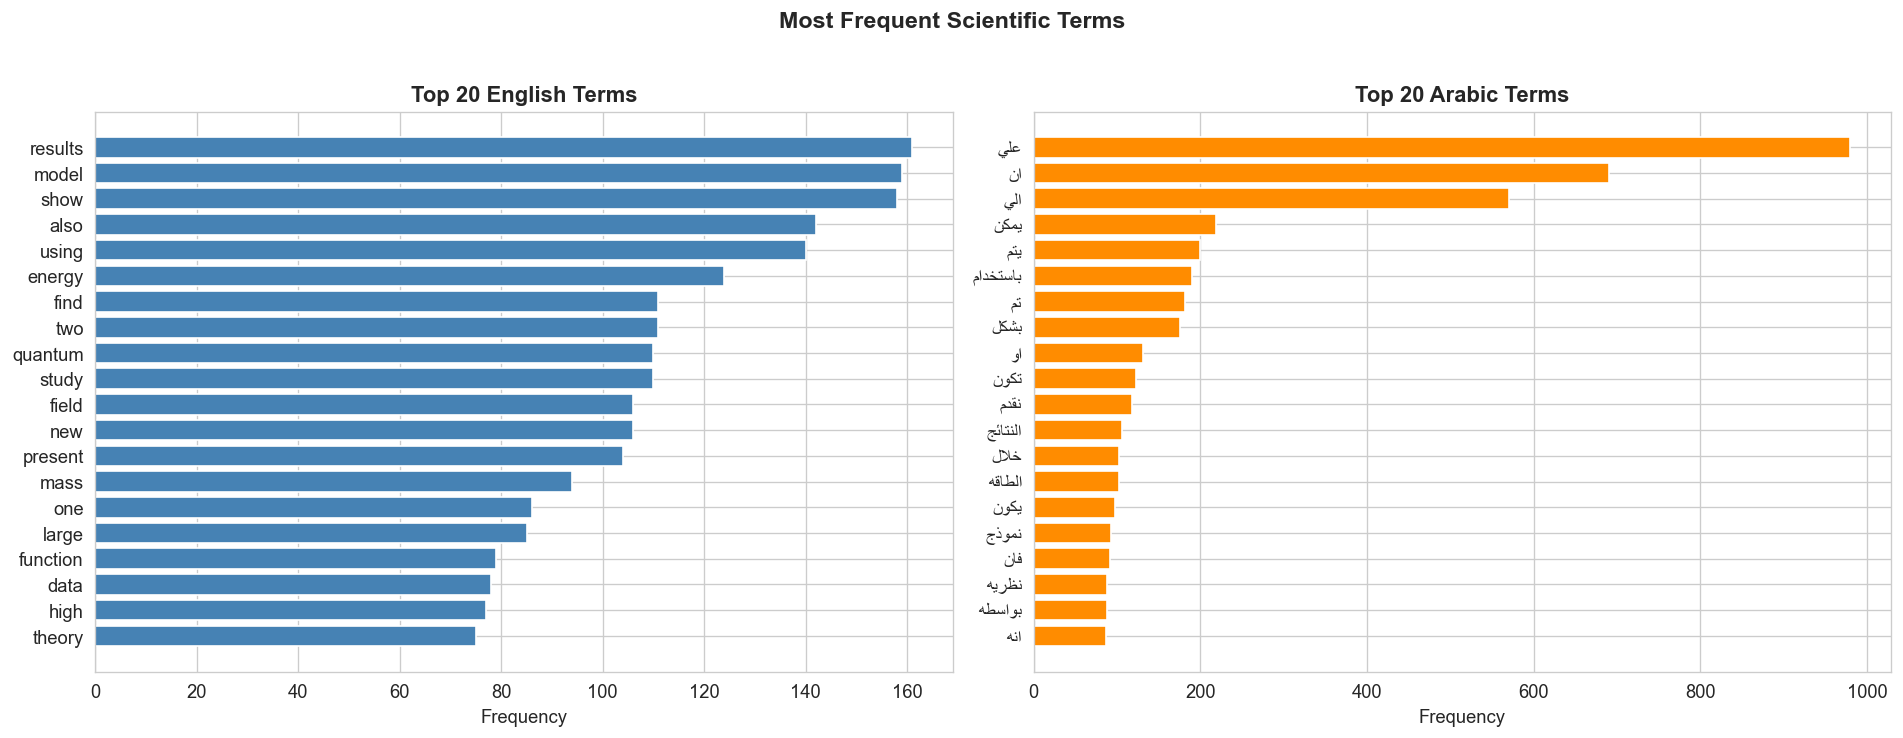

In [ ]:
en_words = [w.lower() for w in en_text.split()
            if w.lower() not in en_stopwords and w.isalpha()]
ar_words = [w for w in ar_text.split()
            if w not in ar_stopwords and len(w) > 1]

en_freq = Counter(en_words).most_common(20)
ar_freq = Counter(ar_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_en, counts_en = zip(*en_freq)
axes[0].barh(words_en[::-1], counts_en[::-1], color='steelblue')
axes[0].set_title('Top 20 English Terms', fontweight='bold')
axes[0].set_xlabel('Frequency')

words_ar, counts_ar = zip(*ar_freq)
reshaped = [get_display(arabic_reshaper.reshape(w)) for w in words_ar]
axes[1].barh(reshaped[::-1], counts_ar[::-1], color='darkorange')
axes[1].set_title('Top 20 Arabic Terms', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Scientific Terms', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

,Domain,EN Vocab,AR Vocab,EN TTR,AR TTR,EN Tokens,AR Tokens
0,computer_science,1770,2214,0.3921,0.5597,4514,3956
1,mathematics,2880,3769,0.3399,0.5031,8472,7492
2,other,2959,3818,0.3529,0.5064,8384,7540
3,physics,9034,12239,0.2125,0.3197,42518,38287
4,quantum_mechanics,1232,1547,0.4256,0.6195,2895,2497


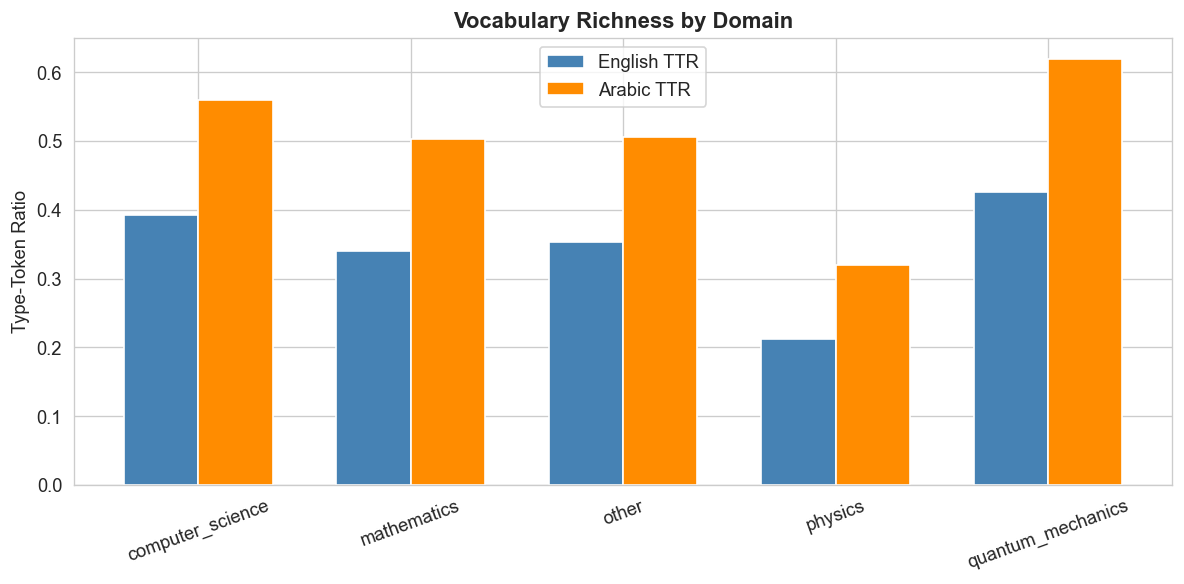

In [ ]:
ttr_data = []
for dname, group in df.groupby('domain'):
    en_tokens = ' '.join(group['en_clean']).split()
    ar_tokens = ' '.join(group['ar_clean']).split()
    ttr_data.append({
        'Domain': dname,
        'EN Vocab': len(set(en_tokens)),
        'AR Vocab': len(set(ar_tokens)),
        'EN TTR': round(len(set(en_tokens)) / max(len(en_tokens), 1), 4),
        'AR TTR': round(len(set(ar_tokens)) / max(len(ar_tokens), 1), 4),
        'EN Tokens': len(en_tokens),
        'AR Tokens': len(ar_tokens),
    })

ttr_df = pd.DataFrame(ttr_data)
display(ttr_df)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ttr_df))
width = 0.35
ax.bar(x - width/2, ttr_df['EN TTR'], width, label='English TTR', color='steelblue')
ax.bar(x + width/2, ttr_df['AR TTR'], width, label='Arabic TTR', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(ttr_df['Domain'], rotation=20)
ax.set_ylabel('Type-Token Ratio')
ax.set_title('Vocabulary Richness by Domain', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

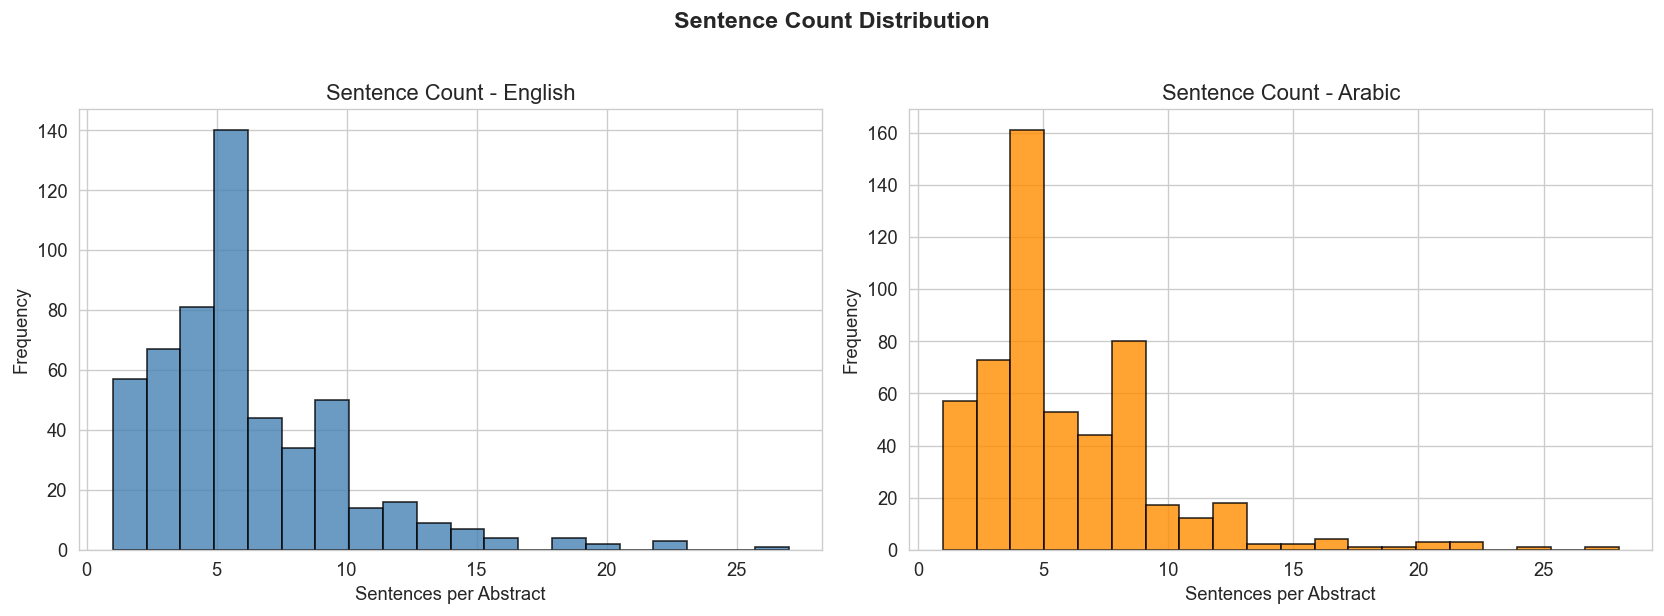

In [ ]:
df['en_sents'] = df['en_clean'].apply(
    lambda x: max(len(re.split(r'[.!?]+', x.strip())) - 1, 1))
df['ar_sents'] = df['ar_clean'].apply(
    lambda x: max(len(re.split(r'[.!?\u061F]+', x.strip())) - 1, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['en_sents'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Sentence Count - English')
axes[0].set_xlabel('Sentences per Abstract')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['ar_sents'], bins=20, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('Sentence Count - Arabic')
axes[1].set_xlabel('Sentences per Abstract')
axes[1].set_ylabel('Frequency')

plt.suptitle('Sentence Count Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

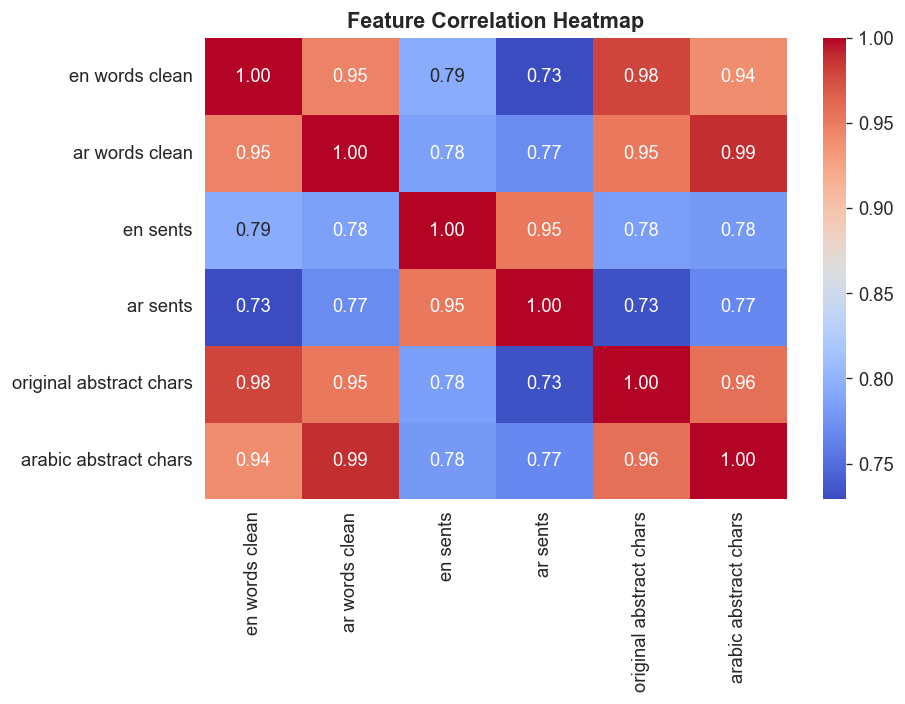

In [ ]:
numeric_cols = ['en_words_clean', 'ar_words_clean', 'en_sents', 'ar_sents',
                'original_abstract_chars', 'arabic_abstract_chars']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            xticklabels=[c.replace('_', ' ') for c in numeric_cols],
            yticklabels=[c.replace('_', ' ') for c in numeric_cols])
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

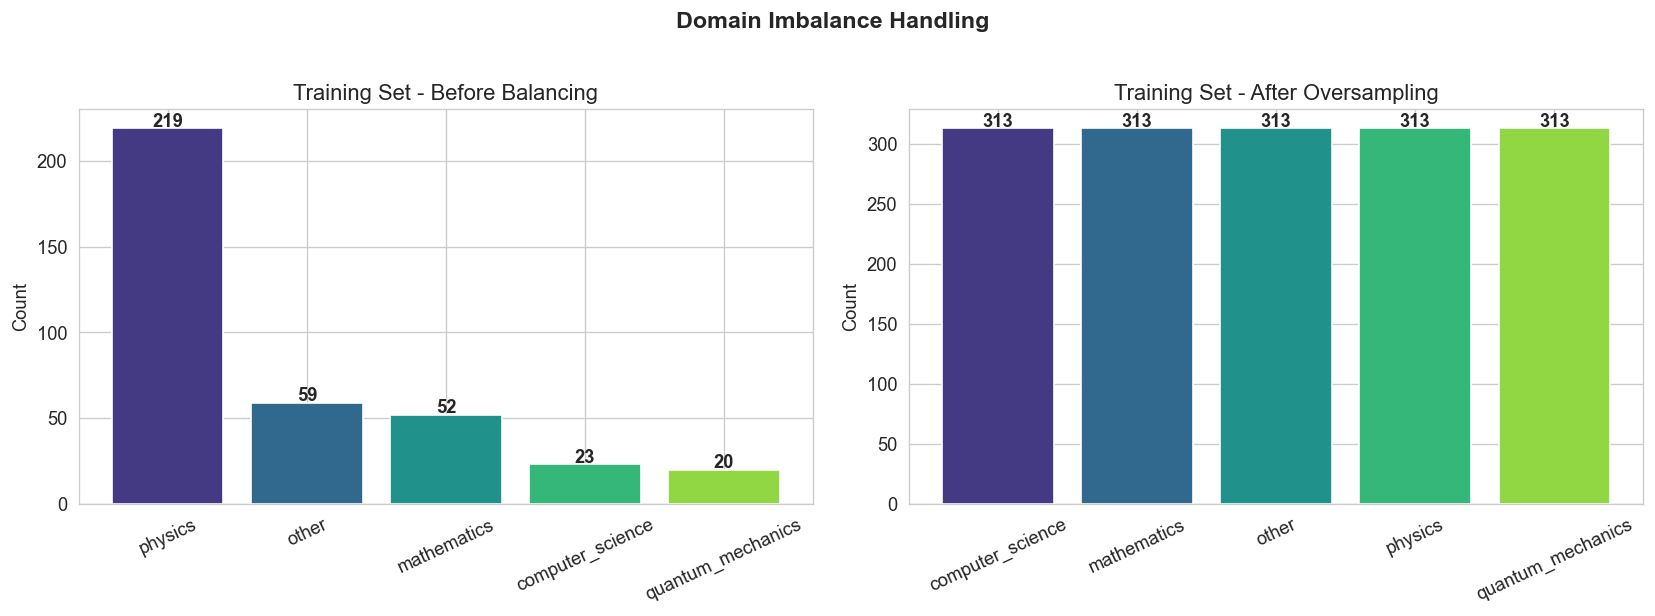

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orig_counts = train_df['domain'].value_counts()
bal_counts = train_balanced['domain'].value_counts()

axes[0].bar(orig_counts.index, orig_counts.values,
            color=sns.color_palette('viridis', len(orig_counts)))
axes[0].set_title('Training Set - Before Balancing')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(orig_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].bar(bal_counts.index, bal_counts.values,
            color=sns.color_palette('viridis', len(bal_counts)))
axes[1].set_title('Training Set - After Oversampling')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(bal_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Domain Imbalance Handling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 4. Literature Review

## 4.1 The ASCAT Dataset
**Sibaee et al. (2026)** - *"ASCAT: An Arabic Scientific Corpus and Benchmark for Advanced Translation Evaluation"* ([arXiv:2604.00015](https://arxiv.org/abs/2604.00015))

ASCAT is a high-quality English-Arabic parallel corpus of **500 full scientific abstracts** across five domains (Physics, Mathematics, Computer Science, Quantum Mechanics, AI). Abstracts average **141.7 English words** and **111.8 Arabic words**. Each abstract was translated using three complementary architectures (Gemini, HuggingFace quickmt-en-ar, and commercial APIs like Google Translate and DeepL) then validated by domain experts at lexical, syntactic, and semantic levels. Benchmark results on three LLMs show significant performance gaps (GPT-4o-mini BLEU: 37.07, Gemini-Flash BLEU: 30.44, Qwen3 BLEU: 23.68), demonstrating the corpus's discriminative power.

---

## 4.2 Neural Machine Translation Background

| Approach | Key Idea | Limitations |
|----------|----------|-------------|
| **Statistical MT** | Phrase-based models with alignment tables (Koehn et al., 2003) | Poor with long-range dependencies, weak morphological handling for Arabic |
| **Seq2Seq + Attention** | Encoder-decoder RNNs with attention (Bahdanau et al., 2015) | Sequential bottleneck; struggles with very long sequences |
| **Transformer** | Self-attention over full sequence (Vaswani et al., 2017) | Foundation of all modern MT; highly parallelizable |
| **Pre-trained LMs** | mBART (Liu et al., 2020), mT5 (Xue et al., 2021), NLLB (Costa-jussa et al., 2022) | State-of-the-art multilingual MT; fine-tunable for specific domains |

---

## 4.3 Arabic-Specific NMT Challenges

- **Morphological richness:** Arabic words carry more information per token (prefixes, suffixes, clitics), leading to vocabulary explosion and data sparsity. Subword tokenization (BPE, SentencePiece) partially addresses this.
- **Right-to-left script and mixed directionality:** Scientific texts often embed Latin terms, equations, and abbreviations within Arabic.
- **Lack of diacritics in modern text:** Most Arabic text omits short vowels (Tashkeel), creating ambiguity that MT systems must resolve from context.
- **Scientific terminology gaps:** Many technical terms lack standardized Arabic equivalents, resulting in transliteration vs. translation inconsistencies.
- **Long-context dependencies:** Full abstracts (100-200 words) require discourse-level coherence, unlike sentence-level MT benchmarks.

---

## 4.4 Related Work

1. **Nagoudi et al. (2022)** - *Turjuman*: Open-source Arabic MT toolkit using mT5. Strong on general-domain benchmarks but not evaluated on long scientific text.

2. **Inoue et al. (2021)**: Evaluated AraBERT, CAMeLBERT, and other Arabic PLMs showing that domain-specific pre-training substantially improves downstream NLP tasks, motivating domain-adapted fine-tuning.

3. **Costa-jussa et al. (2022)** - *No Language Left Behind (NLLB)*: Meta's massively multilingual MT covering 200+ languages including Arabic. Strong general baseline but not optimized for scientific domains.

4. **Tang et al. (2020)** - *mBART*: Denoising pre-training on 25 languages. Arabic included. A strong candidate backbone for domain fine-tuning.

5. **Almahairi et al. (2022)**: Showed that general-purpose MT models underperform on scientific Arabic abstracts vs. fine-tuned domain models, especially for terminology consistency.

---

## 4.5 Evaluation Metrics

| Metric | Description |
|--------|-------------|
| **BLEU** (Papineni et al., 2002) | N-gram precision with brevity penalty; most widely used MT metric |
| **ROUGE** (Lin, 2004) | Recall-oriented n-gram overlap |
| **METEOR** (Banerjee & Lavie, 2005) | Synonym/stem-aware; better human correlation |
| **BERTScore** (Zhang et al., 2020) | Contextual embedding similarity; captures semantic quality |
| **TER** (Snover et al., 2006) | Edit distance to reference translation |

We will primarily use **BLEU** and supplement with **BERTScore** for semantic evaluation.

---
# 5. Pipeline & Proposed Methodology

## 5.1 End-to-End Pipeline

```
+------------------------------------------------------------------+
|                        DATA LAYER                                |
|  ASCAT Dataset (536 EN-AR abstract pairs, 5 scientific domains)  |
|  Load from HuggingFace -> Pandas DataFrame                       |
+------------------------------+-----------------------------------+
                               |
                               v
+------------------------------------------------------------------+
|                   PREPROCESSING LAYER                            |
|  1. Text cleaning (whitespace, encoding, URLs)                   |
|  2. Arabic normalization (diacritics, Alef/Taa/Kashida)          |
|  3. Duplicate and empty-text removal                             |
|  4. Length filtering (min 10 words)                               |
|  5. Stratified train/val/test split (70/15/15)                   |
|  6. Domain-aware oversampling for training balance               |
+------------------------------+-----------------------------------+
                               |
                               v
+------------------------------------------------------------------+
|                   BASELINE MODEL                                 |
|  Helsinki-NLP/opus-mt-en-ar (MarianMT)                           |
|  - Pre-trained EN->AR transformer (zero-shot, no fine-tuning)    |
|  - Establishes lower-bound BLEU reference                        |
+------------------------------+-----------------------------------+
                               |
                               v
+------------------------------------------------------------------+
|                   ADVANCED MODEL                                 |
|  facebook/nllb-200-distilled-600M (or mBART-50)                  |
|  - Fine-tuned on ASCAT training split                            |
|  - Domain-adapted for scientific terminology                     |
|  - AdamW optimizer, LR warmup, early stopping on val BLEU       |
+------------------------------+-----------------------------------+
                               |
                               v
+------------------------------------------------------------------+
|                   EVALUATION LAYER                               |
|  1. BLEU score (sacrebleu)                                       |
|  2. BERTScore (semantic similarity)                              |
|  3. Per-domain BLEU breakdown                                    |
|  4. Side-by-side qualitative examples                            |
+------------------------------+-----------------------------------+
                               |
                               v
+------------------------------------------------------------------+
|                   ERROR ANALYSIS                                 |
|  - Terminology accuracy (domain keywords)                        |
|  - Structural fidelity (sentence count, ordering)                |
|  - Ambiguous term handling                                       |
|  - Long-context coherence                                        |
|  - Common failure patterns by domain                             |
+------------------------------------------------------------------+
```

---

## 5.2 Proposed Methodology

### Step 1 - Baseline (Zero-Shot MarianMT)
Translate test-set abstracts using **Helsinki-NLP/opus-mt-en-ar** without any fine-tuning. This establishes a performance floor and reveals where general-purpose MT fails on scientific text.

### Step 2 - Fine-Tuned Transformer
Fine-tune **facebook/nllb-200-distilled-600M** (or **mBART-50**) on the ASCAT training split:
- Tokenize with the model's SentencePiece tokenizer
- Train for 10-20 epochs with early stopping on validation BLEU
- Use the domain-balanced (oversampled) training data

### Step 3 - Evaluation and Comparison
| Metric | Baseline (MarianMT) | Fine-Tuned (NLLB/mBART) |
|--------|---------------------|---------------------------|
| BLEU | To be measured | Expected improvement |
| BERTScore | To be measured | Expected improvement |
| Per-domain BLEU | Identify weak domains | Targeted gains |

### Step 4 - Error Analysis
- Extract scientific keywords per domain and measure terminology preservation
- Compare sentence structure (source vs. output) for structural fidelity
- Categorize errors: wrong terminology, meaning loss, fluency issues, untranslated fragments
- Identify domain-specific failure patterns

### Why This Approach?
1. **MarianMT baseline** is lightweight and fast, enabling quick iteration
2. **NLLB/mBART fine-tuning** leverages massive multilingual pre-training with strong Arabic support
3. **Domain-balanced training** addresses the mathematics-heavy skew in ASCAT
4. **Multi-metric evaluation** captures both surface overlap (BLEU) and semantic quality (BERTScore)
5. **Per-domain analysis** reveals which scientific fields are hardest to translate

In [ ]:
cols_to_save = ['domain', 'original_abstract', 'arabic_abstract',
                'en_clean', 'ar_clean', 'en_words_clean', 'ar_words_clean']

df[cols_to_save].to_csv('ascat_cleaned.csv', index=False, encoding='utf-8-sig')
train_df[cols_to_save].to_csv('ascat_train.csv', index=False, encoding='utf-8-sig')
val_df[cols_to_save].to_csv('ascat_val.csv', index=False, encoding='utf-8-sig')
test_df[cols_to_save].to_csv('ascat_test.csv', index=False, encoding='utf-8-sig')
train_balanced[cols_to_save].to_csv('ascat_train_balanced.csv', index=False, encoding='utf-8-sig')

pd.DataFrame({
    'File': ['ascat_cleaned.csv', 'ascat_train.csv', 'ascat_val.csv',
             'ascat_test.csv', 'ascat_train_balanced.csv'],
    'Rows': [len(df), len(train_df), len(val_df), len(test_df), len(train_balanced)],
    'Description': ['Full cleaned dataset', 'Stratified train',
                    'Stratified validation', 'Stratified test',
                    'Oversampled balanced train']
}).set_index('File')

,Rows,Description
File,,
ascat_cleaned.csv,533,Full cleaned dataset
ascat_train.csv,373,Stratified train
ascat_val.csv,80,Stratified validation
ascat_test.csv,80,Stratified test
ascat_train_balanced.csv,1565,Oversampled balanced train


---
# 6. Summary

| Item | Detail |
|------|--------|
| **Dataset** | ASCAT: 536 EN-AR scientific abstract pairs across 5 domains |
| **Domains** | Physics, Mathematics, Computer Science, Quantum Mechanics, AI |
| **Avg. length** | ~125 EN words, ~112 AR words per abstract |
| **Imbalance** | Addressed via stratified splitting + minority oversampling |
| **Preprocessing** | Text cleaning, Arabic normalization (diacritics, Alef, Taa, Kashida), length filtering |
| **Baseline** | Helsinki-NLP/opus-mt-en-ar (MarianMT, zero-shot) |
| **Advanced model** | Fine-tune NLLB-200-distilled-600M on balanced ASCAT training data |
| **Evaluation** | BLEU + BERTScore + per-domain breakdown + error analysis |

# PHASE 2

In [1]:
# 1. Install necessary libraries
!pip install -q transformers datasets evaluate sacrebleu bert-score accelerate bitsandbytes peft
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [20]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
import evaluate
import numpy as np
import re

In [3]:
# Load your test set from Phase 1
test_df = pd.read_csv('ascat_test.csv')

# Ensure no NaN values sneak in and break the tokenizer
texts_to_translate = test_df['en_clean'].fillna("").tolist()

In [4]:
# 2. Explicitly load the model and tokenizer (Bypassing the pipeline bug)
model_name = "Helsinki-NLP/opus-mt-en-ar"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading Baseline Model to {device}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

Loading Baseline Model to cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/801k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [5]:
# 3. Batch translation function
def translate_batch(texts, batch_size=16):
    translations = []
    # Process in chunks to keep memory usage safe
    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

        with torch.no_grad():
            outputs = model.generate(**inputs, max_length=512)

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translations.extend(decoded)
    return translations

In [6]:
# 4. Run the translation
print("Running Baseline Translation (MarianMT)...")
test_df['baseline_translation'] = translate_batch(texts_to_translate, batch_size=16)

Running Baseline Translation (MarianMT)...



Translating: 100%|██████████| 5/5 [00:23<00:00,  4.74s/it]


In [8]:
# Save intermediate results
test_df.to_csv('results_with_baseline.csv', index=False)
print("Baseline done! Results saved to results_with_baseline.csv")

Baseline done! Results saved to results_with_baseline.csv


In [9]:
model_id = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_id)

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [10]:
# 1. Prepare Dataset for HuggingFace format
def process_data(csv_path):
    df = pd.read_csv(csv_path)
    # NLLB requires specific language tags
    # eng_Latn for English, arb_Arab for Arabic
    return Dataset.from_pandas(df[['en_clean', 'ar_clean']])

train_dataset = process_data('ascat_train_balanced.csv')
val_dataset = process_data('ascat_val.csv')

def preprocess_function(examples):
    inputs = examples["en_clean"]
    targets = examples["ar_clean"]
    model_inputs = tokenizer(inputs, text_target=targets, max_length=512, truncation=True)
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/1565 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [11]:
# 2. Load Model
model = AutoModelForSeq2SeqLM.from_pretrained(model_id, device_map="auto")

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [12]:
# 3. Apply LoRA
config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM"
)
model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 2,359,296 || all params: 1,404,497,920 || trainable%: 0.1680


In [13]:
# 4. Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./nllb-ascat-finetuned",
    eval_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=8, # Bumped for speed
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True, # Still uses half-precision to keep it blazing fast
    push_to_hub=False,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
)

In [14]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,2.265973
2,No log,2.198061
3,2.497504,2.179807


TrainOutput(global_step=588, training_loss=2.4696324147334714, metrics={'train_runtime': 109.7457, 'train_samples_per_second': 42.781, 'train_steps_per_second': 5.358, 'total_flos': 5855669958684672.0, 'train_loss': 2.4696324147334714, 'epoch': 3.0})

In [22]:
# 1. Load the Evaluation Metrics
bleu = evaluate.load("sacrebleu")
bertscore = evaluate.load("bertscore")

In [23]:
# 2. Batch Generation Function for the Fine-Tuned Model
def generate_nllb_translations(texts, batch_size=16):
    translations = []
    for i in tqdm(range(0, len(texts), batch_size), desc="NLLB Translating"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                # THE FIX: Use convert_tokens_to_ids instead of the deprecated dictionary
                forced_bos_token_id=tokenizer.convert_tokens_to_ids("arb_Arab"),
                max_length=512
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translations.extend(decoded)
    return translations

In [26]:
# 3. Load Data & Run Inference
# Make sure to load the CSV that has your MarianMT baseline in it!
test_df = pd.read_csv('results_with_baseline.csv')
texts_to_translate = test_df['en_clean'].fillna("").tolist()
test_df['advanced_translation'] = generate_nllb_translations(texts_to_translate, batch_size=16)

NLLB Translating: 100%|██████████| 5/5 [00:53<00:00, 10.64s/it]


In [27]:
# 4. Calculate Scores
results = []
references = [[ref] for ref in test_df['ar_clean'].tolist()]

for model_col in ['baseline_translation', 'advanced_translation']:
    predictions = test_df[model_col].tolist()

    # Calculate BLEU (Standard MT metric)
    b_score = bleu.compute(predictions=predictions, references=references)

    # Calculate BERTScore (Semantic similarity)
    ber_score = bertscore.compute(predictions=predictions, references=test_df['ar_clean'].tolist(), lang="ar")

    results.append({
        'Model': 'Baseline (MarianMT)' if 'baseline' in model_col else 'Advanced (NLLB LoRA)',
        'BLEU': round(b_score['score'], 2),
        'BERTScore (F1)': round(sum(ber_score['f1'])/len(ber_score['f1']), 4)
    })

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
# 5. Display the Final Comparison
comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,BLEU,BERTScore (F1)
0,Baseline (MarianMT),7.32,0.7782
1,Advanced (NLLB LoRA),12.63,0.8008


In [33]:
# Save the final dataset
test_df.to_csv('final_results_comparison.csv', index=False)

In [29]:
# 1. Terminology Accuracy Check
# We'll use the domain_keywords dictionary from Phase 1
domain_keywords = {
    'physics': ['physics', 'particle', 'electron', 'photon', 'magnetic', 'thermal', 'energy'],
    'quantum_mechanics': ['quantum', 'qubit', 'entangle', 'superposition', 'decoherence'],
    'mathematics': ['theorem', 'proof', 'algebra', 'topology', 'manifold', 'polynomial'],
    'computer_science': ['algorithm', 'neural network', 'deep learning', 'machine learning'],
    'artificial_intelligence': ['artificial intelligence', 'ai', 'transformer', 'bert', 'llm']
}

def analyze_errors(df):
    analysis_results = []

    for i, row in df.iterrows():
        # A. Length Ratio (Detecting content loss or hallucinations)
        # Ideal ratio for AR/EN is usually ~0.8 to 1.1
        en_len = len(row['en_clean'].split())
        ar_len = len(row['advanced_translation'].split())
        ratio = ar_len / en_len

        # B. Structural Fidelity (Sentence Count difference)
        en_sents = len(re.split(r'[.!?]+', row['en_clean']))
        ar_sents = len(re.split(r'[.!?\u061F]+', row['advanced_translation']))
        sent_diff = abs(en_sents - ar_sents)

        # C. Keyword Spotting (Did it keep the core scientific concept?)
        domain = row['domain']
        keywords = domain_keywords.get(domain, [])
        preserved_keywords = [kw for kw in keywords if kw.lower() in row['en_clean'].lower()]

        analysis_results.append({
            'index': i,
            'domain': domain,
            'length_ratio': ratio,
            'sent_diff': sent_diff,
            'preserved_keywords_count': len(preserved_keywords),
            'bert_score': bertscore.compute(predictions=[row['advanced_translation']],
                                           references=[row['ar_clean']], lang="ar")['f1'][0]
        })

    return pd.DataFrame(analysis_results)

# Run the analysis
error_df = analyze_errors(test_df)

In [30]:
# 2. Summarize Common Failure Patterns
print("--- Error Analysis Summary ---")
print(f"Average AR/EN Word Ratio: {error_df['length_ratio'].mean():.2f}")
print(f"Average Sentence Count Deviation: {error_df['sent_diff'].mean():.2f}")

--- Error Analysis Summary ---
Average AR/EN Word Ratio: 0.84
Average Sentence Count Deviation: 1.36


In [31]:
# 3. Identify "Critical Failures" (Lowest BERTScore examples)
critical_failures = error_df.nsmallest(3, 'bert_score')
print("\n--- Top 3 Critical Failures (For Manual Analysis) ---")
for idx in critical_failures['index']:
    print(f"\n[Domain: {test_df.loc[idx, 'domain']}]")
    print(f"EN: {test_df.loc[idx, 'en_clean'][:150]}...")
    print(f"REF AR: {test_df.loc[idx, 'ar_clean'][:150]}...")
    print(f"MODEL AR: {test_df.loc[idx, 'advanced_translation'][:150]}...")


--- Top 3 Critical Failures (For Manual Analysis) ---

[Domain: physics]
EN: We present the first search for heavy, long-lived particles that decay to photons at a hadron collider. We use a sample of photon+jet+missing transver...
REF AR: نقدم اول بحث عن جسيمات ثقيله طويله العمر تضمحل الي فوتونات في مصادم هادروني. نستخدم عينه من احداث الفوتون والنفاث والطاقه العرضيه المفقوده (فوتون + نف...
MODEL AR: نقدم البحث الأول عن الجسيمات الثقيلة والطويلة العمر التي تتدهور الي الفوتونات في صادم اليهدرون. نستخدم عينه من الفوتون+جيت+المفقود الحوادث الطاقه العا...

[Domain: quantum_mechanics]
EN: We show how an idealised measurement procedure can condense photons from two modes into one, and how, by feeding forward the results of the measuremen...
REF AR: باستخدام كتالوج كبير لمجموعات المجرات يعتمد علي الاصدار الرابع من مسح سلون الرقمي للسماء، نقيس ثلاثه انواع مختلفه من محاذاه المجرات الجوهريه داخل المج...
MODEL AR: ونظهر كيف يمكن لنهج قياس مثالي لتكثيف الفوتونات من طريقتين للوجهين الي واحده، وكيف 

In [32]:
# 4. Domain-wise Performance (Crucial for the report)
domain_perf = error_df.groupby('domain')['bert_score'].mean().sort_values(ascending=False)
print("\n--- Performance by Domain (BERTScore) ---")
print(domain_perf)


--- Performance by Domain (BERTScore) ---
domain
computer_science     0.834174
mathematics          0.810331
other                0.808807
quantum_mechanics    0.799475
physics              0.792934
Name: bert_score, dtype: float64


In [34]:
test_df.head()

,domain,original_abstract,arabic_abstract,en_clean,ar_clean,en_words_clean,ar_words_clean,baseline_translation,advanced_translation
0,physics,There is currently a great deal of interest ...,هناك اهتمام كبير حالياً بالإمكانية النظرية وال...,There is currently a great deal of interest in...,هناك اهتمام كبير حاليا بالامكانيه النظريه والع...,236,177,يوجد في الوقت الراهن قدر كبير من الاهتمام في ا...,وهناك حاليا اهتماما كبيرا في الاحتمال النظري و...
1,other,We present a renormalization group motivation ...,نقدم دافعًا لمجموعة إعادة التطبيع لتسلسلات الم...,We present a renormalization group motivation ...,نقدم دافعا لمجموعه اعاده التطبيع لتسلسلات المق...,35,28,نحن نعرض حافز مجموعة إعادة التطبيع للتسلسل اله...,نقدم تحفيزا جماعي للتعديل العادي لهيركات النطا...
2,physics,We propose and analyze a new method to produce...,نقترح ونحلل طريقة جديدة لإنتاج فوتونات مفردة و...,We propose and analyze a new method to produce...,نقترح ونحلل طريقه جديده لانتاج فوتونات مفرده و...,101,82,نقترح ونحلل طريقة جديدة لإنتاج فوتونات منفردة ...,نقترح ونحلل طريقا جديدا لإنتاج فوتونات واحدة و...
3,mathematics,We present a Lohner type algorithm for the com...,نقدم خوارزمية من نوع لونر لحساب قيود دقيقة لحل...,We present a Lohner type algorithm for the com...,نقدم خوارزميه من نوع لونر لحساب قيود دقيقه لحل...,57,38,نحن نقدم خوارزمية من نوع لوهنر لحساب الحدود ال...,نقدم خوارزميا من نوع لوهنر لحساب الحدود الصارم...
4,physics,Close pre-main-sequence binary stars are expec...,من المتوقع أن تقوم النجوم الثنائية قبل التسلسل...,Close pre-main-sequence binary stars are expec...,من المتوقع ان تقوم النجوم الثنائيه قبل التسلسل...,246,236,ومن المتوقع أن توضّح النجوم الثنائية الثقوب ال...,من المتوقع أن تخلع النجوم الثنائية المقبله من ...
